## IIP314W Optimización aplicada a negocios

### Ayudantía 1

## Repaso conceptual

### Formulación de un problema

Un problema de optimización requiere de:

> Variables de decisión.
> 
> Función objetivo.
> 
> Restricciones (igualdad/desigualdad).

Forma general:

$$\min f(x) \quad \text{sujeto a } g_i(x)\le 0,\; h_j(x)=0$$

### Puntos críticos y clasificación

- Punto crítico: $f'(x)=0$ (1D) o $\nabla f(x)=0$ (multivariable).
- Clasificación local: máximo, mínimo o silla/inflexión.
- Criterio de segundo orden: signo de segunda derivada (1D) o Hessiano (multivariable).

### Equivalencia max -> -min

$$\max f(x) = \min(-f(x))$$

> Usar esta equivalencia permite resolver sistemáticamente en formato de minimización.

### Descenso de gradiente (resumen operativo)

Actualización iterativa:

$$x_{k+1}=x_k-\alpha\nabla f(x_k)$$

Parámetros críticos:

- Inicialización $x_0$.--> Valor de X inicial
- Tasa de aprendizaje $\alpha$. --> Paso o razón de cambio
- Tolerancia --> diferencia entre el paso actual y el anterior mínima para seguir iterando.
- Máximo de iteraciones. --> se explica solo.

### Ejercicio 1 (1 variable)

Considere:

$$f(t)=-t^2+6t,\quad t\in[0,6]$$

**Tareas**:
1. Calcular $f'(t)$ y resolver $f'(t)=0$.
2. Clasificar el punto crítico con segunda derivada.
3. Verificar el valor de la función en extremos y punto crítico.

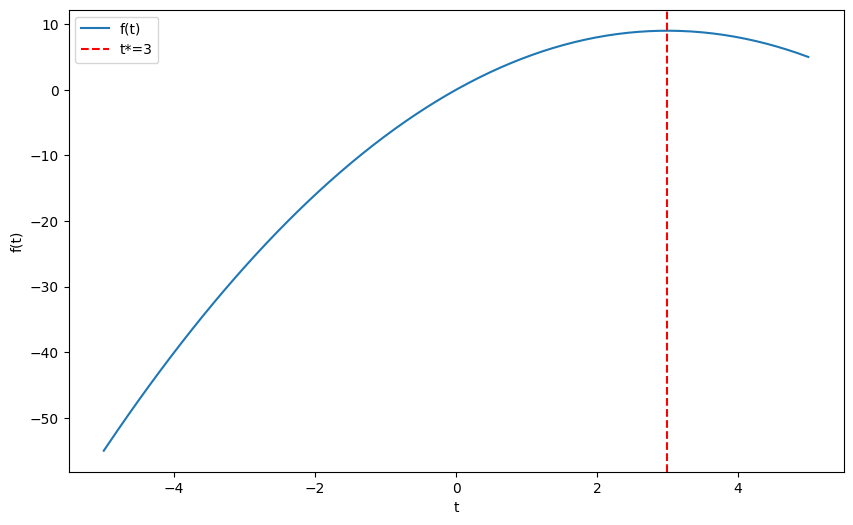

In [5]:
import numpy as np
import matplotlib.pyplot as plt
f = lambda t: -t**2 +6*t
df = lambda t: -2*t + 6

optimo = 3
x =np.linspace(-5,5, 200)
plt.figure(figsize=(10,6))
plt.plot(x, f(x), label='f(t)')
plt.axvline(optimo, color='red', linestyle='--', label='t*=3')
plt.legend()
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

### Ejercicio 2 (2 variables)

Considere:

$$f(x,y)=2x^2-xy+y^2-7y$$

**Tareas**:
1. Hallar $\nabla f(x,y)$.
2. Resolver sistema de primer orden para el punto estacionario.
3. Clasificar usando Hessiano.

In [8]:
import sympy as sp

x, y = sp.symbols('x y', real=True)
z = 2*x**2 - x*y + y**2 - 7*y
gard = [sp.diff(z, x), sp.diff(z, y)]

sol = sp.solve(gard, (x, y))
H = sp.hessian(z, (x, y))

print(gard)
display(H)
print(sol)

[4*x - y, -x + 2*y - 7]


Matrix([
[ 4, -1],
[-1,  2]])

{x: 1, y: 4}


### Ejercicio 3 (descenso de gradiente sobre función cuadrática)

Considere:

$$q(x)=(x+1)^2$$

**Tareas**:
1. Implementar descenso de gradiente en 1D.
2. Evaluar sensibilidad frente a diferentes $\alpha$.
3. Registrar iteraciones hasta criterio de parada.

In [15]:
f = lambda x: x**2 + 2*x +1
df = lambda x: 2*x + 2
def gr(x, tol=1e-6, alpha=0.5, iter=100):
    x = x
    hist = [x]
    for _ in range(iter):
        xn = x-alpha*df(x)
        hist.append(xn)
        if abs(xn-x) <tol:
            break
        x = xn
    return x, hist



x_aprox, historial= gr(1)
x_aprox, f(x_aprox), len(historial)

(-1.0, 0.0, 3)